In [1]:
import pandas as pd

DATA_PATH = "../data/consolidated_traffic_data.csv"

df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {df.shape}")

Dataset shape: (59706, 24)


In [2]:
print("Columns:")
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

Columns:
1. duration
2. total_fiat
3. total_biat
4. min_fiat
5. min_biat
6. max_fiat
7. max_biat
8. mean_fiat
9. mean_biat
10. flowPktsPerSecond
11. flowBytesPerSecond
12. min_flowiat
13. max_flowiat
14. mean_flowiat
15. std_flowiat
16. min_active
17. mean_active
18. max_active
19. std_active
20. min_idle
21. mean_idle
22. max_idle
23. std_idle
24. traffic_type


In [3]:
print("Traffic types:")
print(df["traffic_type"].value_counts())

Traffic types:
traffic_type
BROWSING         10000
VPN-BROWSING     10000
VOIP              6485
VPN-VOIP          5576
VPN-FT            4704
P2P               4000
FT                3975
VPN-P2P           3415
VPN-CHAT          2839
CHAT              2505
VPN-MAIL          2444
MAIL              1364
STREAMING         1284
VPN-STREAMING     1115
Name: count, dtype: int64


In [4]:
pd.set_option("display.max_columns", None)

df.head()

,duration,total_fiat,total_biat,min_fiat,min_biat,max_fiat,max_biat,mean_fiat,mean_biat,flowPktsPerSecond,flowBytesPerSecond,min_flowiat,max_flowiat,mean_flowiat,std_flowiat,min_active,mean_active,max_active,std_active,min_idle,mean_idle,max_idle,std_idle,traffic_type
0,119994459.0,119994459.0,119970125.0,0.0,0.0,1399330.0,1211310.0,2348.136257,513.267526,2373.792943,2.724140e+06,0.0,1208289.0,421.268213,9107.759178,1753114.0,11300000.0,39438693.0,1.600000e+07,1014624.0,1139537.6,1208289.0,74997.385381,BROWSING
1,143704195.0,143704195.0,42106019.0,0.0,0.0,101572528.0,854818.0,6986.105737,636.898837,603.204381,6.452134e+05,0.0,101572528.0,1657.832018,345078.175888,143704195.0,144000000.0,143704195.0,0.000000e+00,101572528.0,102000000.0,101572528.0,0.000000,BROWSING
2,119994980.0,119994980.0,119966891.0,7.0,0.0,819852.0,819602.0,10201.919742,2341.411304,525.030297,5.971361e+05,0.0,819581.0,1904.682222,17736.017265,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
3,119292282.0,119292282.0,119260024.0,3.0,0.0,912990.0,866900.0,11947.148923,3354.712349,381.726288,4.173306e+05,0.0,837920.0,2619.735638,24218.472201,-1.0,0.0,-1.0,0.000000e+00,-1.0,0.0,-1.0,0.000000,BROWSING
4,119772966.0,119772917.0,119772939.0,4.0,0.0,2894671.0,2923147.0,18210.873803,3644.280989,329.331412,3.833541e+05,0.0,2894671.0,3036.531944,31326.437353,2210292.0,8688035.0,15165778.0,9.160912e+06,1799762.0,2347216.5,2894671.0,774217.578682,BROWSING


In [5]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Data types:
duration              float64
total_fiat            float64
total_biat            float64
min_fiat              float64
min_biat              float64
max_fiat              float64
max_biat              float64
mean_fiat             float64
mean_biat             float64
flowPktsPerSecond     float64
flowBytesPerSecond    float64
min_flowiat           float64
max_flowiat           float64
mean_flowiat          float64
std_flowiat           float64
min_active            float64
mean_active           float64
max_active            float64
std_active            float64
min_idle              float64
mean_idle             float64
max_idle              float64
std_idle              float64
traffic_type           object
dtype: object

Missing values:
duration              0
total_fiat            0
total_biat            0
min_fiat              0
min_biat              0
max_fiat              0
max_biat              0
mean_fiat             0
mean_biat             0
flowPktsPerSecond    

In [6]:
print("Number of -1 values in each feature:")
print((df.drop(columns="traffic_type") == -1).sum())

Number of -1 values in each feature:
duration                  0
total_fiat                0
total_biat                0
min_fiat               8846
min_biat              13857
max_fiat               8846
max_biat              13857
mean_fiat                 0
mean_biat                 0
flowPktsPerSecond         0
flowBytesPerSecond        0
min_flowiat            2289
max_flowiat            2108
mean_flowiat              0
std_flowiat               0
min_active            32228
mean_active               0
max_active            32228
std_active                0
min_idle              32228
mean_idle                 0
max_idle              32228
std_idle                  0
dtype: int64


In [7]:
features_with_minus_one = [
    "min_fiat",
    "min_biat",
    "max_fiat",
    "max_biat",
    "min_flowiat",
    "max_flowiat",
    "min_active",
    "max_active",
    "min_idle",
    "max_idle",
]

for feature in features_with_minus_one:
    print(f"\n{feature}:")
    print(
        df.loc[df[feature] == -1, "traffic_type"]
        .value_counts()
    )


min_fiat:
traffic_type
P2P              1991
VPN-P2P          1607
VPN-BROWSING     1333
VPN-FT            981
VPN-VOIP          732
FT                723
CHAT              507
VPN-CHAT          408
STREAMING         336
VOIP              106
MAIL               61
VPN-MAIL           45
VPN-STREAMING      14
BROWSING            2
Name: count, dtype: int64

min_biat:
traffic_type
VPN-P2P          2190
P2P              2004
VPN-FT           1513
VPN-BROWSING     1441
FT               1394
VPN-MAIL         1336
VPN-VOIP          808
MAIL              775
CHAT              669
VPN-CHAT          630
VOIP              480
STREAMING         413
VPN-STREAMING     138
BROWSING           66
Name: count, dtype: int64

max_fiat:
traffic_type
P2P              1991
VPN-P2P          1607
VPN-BROWSING     1333
VPN-FT            981
VPN-VOIP          732
FT                723
CHAT              507
VPN-CHAT          408
STREAMING         336
VOIP              106
MAIL               61
VPN-MAIL          

In [8]:
active_idle_cols = [
    "min_active",
    "mean_active",
    "max_active",
    "std_active",
    "min_idle",
    "mean_idle",
    "max_idle",
    "std_idle",
]

print(
    df.loc[
        (df["min_active"] == -1) &
        (df["max_active"] == -1) &
        (df["min_idle"] == -1) &
        (df["max_idle"] == -1),
        active_idle_cols
    ].head(10)
)

    min_active  mean_active  max_active  std_active  min_idle  mean_idle  \
2         -1.0          0.0        -1.0         0.0      -1.0        0.0   
3         -1.0          0.0        -1.0         0.0      -1.0        0.0   
5         -1.0          0.0        -1.0         0.0      -1.0        0.0   
9         -1.0          0.0        -1.0         0.0      -1.0        0.0   
13        -1.0          0.0        -1.0         0.0      -1.0        0.0   
14        -1.0          0.0        -1.0         0.0      -1.0        0.0   
15        -1.0          0.0        -1.0         0.0      -1.0        0.0   
16        -1.0          0.0        -1.0         0.0      -1.0        0.0   
18        -1.0          0.0        -1.0         0.0      -1.0        0.0   
20        -1.0          0.0        -1.0         0.0      -1.0        0.0   

    max_idle  std_idle  
2       -1.0       0.0  
3       -1.0       0.0  
5       -1.0       0.0  
9       -1.0       0.0  
13      -1.0       0.0  
14      -1.0 

In [9]:
print("\nRows where min_active == -1:")
print(
    df.loc[df["min_active"] == -1, active_idle_cols]
    .drop_duplicates()
    .head(20)
)


Rows where min_active == -1:
   min_active  mean_active  max_active  std_active  min_idle  mean_idle  \
2        -1.0          0.0        -1.0         0.0      -1.0        0.0   

   max_idle  std_idle  
2      -1.0       0.0  


In [10]:
feature_columns = df.drop(columns="traffic_type").columns

df[feature_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,59706.0,2.354579e+07,3.610462e+07,0.0,256160.000000,1.306654e+07,2.998854e+07,646565983.0
total_fiat,59706.0,2.215066e+07,3.465348e+07,0.0,111687.500000,1.168921e+07,2.993403e+07,646565983.0
total_biat,59706.0,2.049105e+07,2.968948e+07,0.0,2625.000000,1.028447e+07,2.968528e+07,601185122.0
min_fiat,59706.0,2.044648e+06,7.919716e+06,-1.0,7.000000,6.400000e+01,3.090250e+03,119999708.0
min_biat,59706.0,1.779203e+06,7.455655e+06,-1.0,0.000000,2.000000e+01,5.037500e+02,119999620.0
max_fiat,59706.0,9.063199e+06,2.522047e+07,-1.0,25972.000000,5.371380e+05,9.829409e+06,646287731.0
max_biat,59706.0,7.591169e+06,1.704812e+07,-1.0,1738.000000,3.828470e+05,9.521396e+06,600109667.0
mean_fiat,59706.0,3.190482e+06,9.150407e+06,0.0,7927.111931,1.016749e+05,1.071742e+06,152000000.0
mean_biat,59706.0,2.776105e+06,8.073066e+06,0.0,336.445092,5.391917e+04,9.615569e+05,120000000.0
flowPktsPerSecond,59706.0,4.035707e+03,2.858908e+04,0.0,0.959502,8.545710e+00,1.001268e+02,2000000.0


In [11]:
negative_counts = (
    df.drop(columns="traffic_type") < 0
).sum()

print("Negative values in each feature:")
print(negative_counts[negative_counts > 0])

Negative values in each feature:
min_fiat        8846
min_biat       13857
max_fiat        8846
max_biat       13857
min_flowiat     2694
max_flowiat     2108
min_active     32228
max_active     32228
min_idle       32228
max_idle       32228
dtype: int64


In [12]:
negative_details = {}

for col in df.select_dtypes(include="number").columns:
    negatives = df.loc[df[col] < 0, col]

    if len(negatives) > 0:
        negative_details[col] = {
            "count": len(negatives),
            "unique_values": negatives.nunique(),
            "min": negatives.min(),
            "max": negatives.max(),
            "most_common": negatives.value_counts().head(10).to_dict()
        }

negative_details

{'min_fiat': {'count': 8846,
  'unique_values': 1,
  'min': np.float64(-1.0),
  'max': np.float64(-1.0),
  'most_common': {-1.0: 8846}},
 'min_biat': {'count': 13857,
  'unique_values': 1,
  'min': np.float64(-1.0),
  'max': np.float64(-1.0),
  'most_common': {-1.0: 13857}},
 'max_fiat': {'count': 8846,
  'unique_values': 1,
  'min': np.float64(-1.0),
  'max': np.float64(-1.0),
  'most_common': {-1.0: 8846}},
 'max_biat': {'count': 13857,
  'unique_values': 1,
  'min': np.float64(-1.0),
  'max': np.float64(-1.0),
  'most_common': {-1.0: 13857}},
 'min_flowiat': {'count': 2694,
  'unique_values': 88,
  'min': np.float64(-1247.0),
  'max': np.float64(-1.0),
  'most_common': {-1.0: 2289,
   -2.0: 57,
   -3.0: 21,
   -4.0: 12,
   -8.0: 12,
   -39.0: 12,
   -43.0: 9,
   -9.0: 9,
   -41.0: 8,
   -28.0: 8}},
 'max_flowiat': {'count': 2108,
  'unique_values': 1,
  'min': np.float64(-1.0),
  'max': np.float64(-1.0),
  'most_common': {-1.0: 2108}},
 'min_active': {'count': 32228,
  'unique_value

In [13]:
negative_percentage = (
    (df.drop(columns="traffic_type") < 0).mean() * 100
)

print("Percentage of negative values:")
print(negative_percentage[negative_percentage > 0].sort_values(ascending=False))

Percentage of negative values:
min_idle       53.977825
max_idle       53.977825
max_active     53.977825
min_active     53.977825
max_biat       23.208723
min_biat       23.208723
min_fiat       14.815931
max_fiat       14.815931
min_flowiat     4.512109
max_flowiat     3.530633
dtype: float64


In [14]:
feature_stats = pd.DataFrame({
    "unique_values": df.drop(columns="traffic_type").nunique(),
    "zero_count": (df.drop(columns="traffic_type") == 0).sum(),
    "zero_percentage": (df.drop(columns="traffic_type") == 0).mean() * 100
})

print(feature_stats.sort_values("zero_percentage", ascending=False))

                    unique_values  zero_count  zero_percentage
std_idle                    12933       43847        73.438180
std_active                  12904       43847        73.438180
mean_active                 11740       32228        53.977825
mean_idle                   12789       32228        53.977825
total_biat                  34452       13858        23.210398
mean_biat                   30172       13858        23.210398
std_flowiat                 33085       10749        18.003216
mean_fiat                   31523        8846        14.815931
total_fiat                  35952        8846        14.815931
min_flowiat                  6397        3031         5.076542
flowPktsPerSecond           39829        2110         3.533983
duration                    38926        2110         3.533983
mean_flowiat                37911        2110         3.533983
flowBytesPerSecond          40425        2110         3.533983
min_biat                     7992        1666         2

In [15]:
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")

Duplicate rows: 18719
Duplicate percentage: 31.35%


In [16]:
duplicate_rows = df[df.duplicated(keep=False)].sort_values(
    by=list(df.columns)
)

print(f"Rows involved in duplicates: {len(duplicate_rows)}")

print("\nDuplicate feature rows with different labels:")

feature_columns = df.columns.drop("traffic_type")

duplicate_label_conflicts = (
    duplicate_rows
    .groupby(list(feature_columns))["traffic_type"]
    .nunique()
)

print(
    f"Feature combinations having multiple labels: "
    f"{(duplicate_label_conflicts > 1).sum()}"
)

Rows involved in duplicates: 26057

Duplicate feature rows with different labels:
Feature combinations having multiple labels: 76


In [17]:
conflicting_features = duplicate_label_conflicts[
    duplicate_label_conflicts > 1
]

print(f"Conflicting feature combinations: {len(conflicting_features)}")

print("\nNumber of labels per conflicting feature combination:")
print(conflicting_features.value_counts())

print("\nExample conflicting combinations:")
print(conflicting_features.head(10))

Conflicting feature combinations: 76

Number of labels per conflicting feature combination:
traffic_type
2     61
3     14
13     1
Name: count, dtype: int64

Example conflicting combinations:
duration  total_fiat  total_biat  min_fiat  min_biat  max_fiat  max_biat  mean_fiat  mean_biat  flowPktsPerSecond  flowBytesPerSecond  min_flowiat  max_flowiat  mean_flowiat  std_flowiat  min_active  mean_active  max_active  std_active  min_idle  mean_idle  max_idle  std_idle
0.0       0.0         0.0         -1.0      -1.0      -1.0      -1.0      0.0        0.0        0.000000           0.000000e+00        -1.0         -1.0         0.0           0.0          -1.0        0.0          -1.0        0.0         -1.0      0.0        -1.0      0.0         13
3.0       0.0         0.0         -1.0      -1.0      -1.0      -1.0      0.0        0.0        666666.666667      3.070000e+07         3.0          3.0         3.0           0.0          -1.0        0.0          -1.0        0.0         -1.0      

In [19]:
feature_columns = df.columns.drop("traffic_type")

X = df[feature_columns]
y = df["traffic_type"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(list(X.columns))

print("\nTarget classes:")
print(y.unique())
print(y.value_counts())

X shape: (59706, 23)
y shape: (59706,)

Features:
['duration', 'total_fiat', 'total_biat', 'min_fiat', 'min_biat', 'max_fiat', 'max_biat', 'mean_fiat', 'mean_biat', 'flowPktsPerSecond', 'flowBytesPerSecond', 'min_flowiat', 'max_flowiat', 'mean_flowiat', 'std_flowiat', 'min_active', 'mean_active', 'max_active', 'std_active', 'min_idle', 'mean_idle', 'max_idle', 'std_idle']

Target classes:
['BROWSING' 'CHAT' 'FT' 'MAIL' 'P2P' 'STREAMING' 'VOIP' 'VPN-BROWSING'
 'VPN-CHAT' 'VPN-FT' 'VPN-MAIL' 'VPN-P2P' 'VPN-STREAMING' 'VPN-VOIP']
traffic_type
BROWSING         10000
VPN-BROWSING     10000
VOIP              6485
VPN-VOIP          5576
VPN-FT            4704
P2P               4000
FT                3975
VPN-P2P           3415
VPN-CHAT          2839
CHAT              2505
VPN-MAIL          2444
MAIL              1364
STREAMING         1284
VPN-STREAMING     1115
Name: count, dtype: int64


In [20]:
groups = X.astype(str).agg("|".join, axis=1)

print("Total samples:", len(X))
print("Unique feature combinations:", groups.nunique())
print("Duplicate feature combinations:", len(X) - groups.nunique())

Total samples: 59706
Unique feature combinations: 40728
Duplicate feature combinations: 18978


In [21]:
from sklearn.model_selection import GroupShuffleSplit

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("Training set:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTest set:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training set:
X_train: (48279, 23)
y_train: (48279,)

Test set:
X_test: (11427, 23)
y_test: (11427,)


In [22]:
print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())


Training class distribution:
traffic_type
BROWSING         8059
VPN-BROWSING     8031
VOIP             5197
VPN-VOIP         4485
VPN-FT           3765
FT               3320
P2P              3208
VPN-P2P          2869
VPN-CHAT         2277
CHAT             2040
VPN-MAIL         1997
MAIL             1086
STREAMING        1052
VPN-STREAMING     893
Name: count, dtype: int64

Test class distribution:
traffic_type
VPN-BROWSING     1969
BROWSING         1941
VOIP             1288
VPN-VOIP         1091
VPN-FT            939
P2P               792
FT                655
VPN-CHAT          562
VPN-P2P           546
CHAT              465
VPN-MAIL          447
MAIL              278
STREAMING         232
VPN-STREAMING     222
Name: count, dtype: int64


In [23]:
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

def replace_negative_with_nan(X):
    X = X.copy()
    X[X < 0] = np.nan
    return X

preprocessor = Pipeline([
    (
        "negative_to_nan",
        FunctionTransformer(
            replace_negative_with_nan,
            feature_names_out="one-to-one"
        )
    ),
    (
        "imputer",
        SimpleImputer(strategy="median")
    )
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Processed X_train shape:", X_train_processed.shape)

print("\nOriginal X_test shape:", X_test.shape)
print("Processed X_test shape:", X_test_processed.shape)

print("\nMissing values after preprocessing:")
print("Train:", np.isnan(X_train_processed).sum())
print("Test:", np.isnan(X_test_processed).sum())

Original X_train shape: (48279, 23)
Processed X_train shape: (48279, 23)

Original X_test shape: (11427, 23)
Processed X_test shape: (11427, 23)

Missing values after preprocessing:
Train: 0
Test: 0


In [24]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_processed, y_train)

y_pred = model.predict(X_test_processed)

accuracy = accuracy_score(y_test, y_pred)

print(f"Test Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.8478

Classification Report:
               precision    recall  f1-score   support

     BROWSING       0.86      0.90      0.88      1941
         CHAT       0.76      0.77      0.76       465
           FT       0.92      0.84      0.88       655
         MAIL       0.69      0.80      0.74       278
          P2P       0.86      0.89      0.88       792
    STREAMING       0.72      0.69      0.70       232
         VOIP       0.98      0.98      0.98      1288
 VPN-BROWSING       0.82      0.87      0.84      1969
     VPN-CHAT       0.72      0.67      0.70       562
       VPN-FT       0.79      0.78      0.78       939
     VPN-MAIL       0.88      0.68      0.77       447
      VPN-P2P       0.77      0.60      0.68       546
VPN-STREAMING       0.81      0.87      0.84       222
     VPN-VOIP       0.92      0.96      0.94      1091

     accuracy                           0.85     11427
    macro avg       0.82      0.81      0.81     11427
 weighted avg    

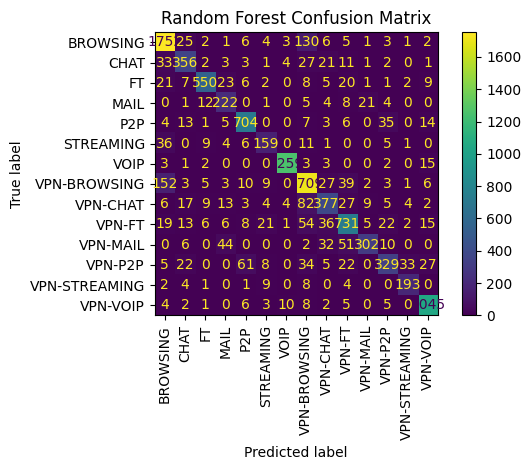

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    xticks_rotation="vertical"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()